In [2]:
import os
import sys
from ipywidgets import interact

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_notebook import *

%matplotlib widget

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/demi_cycle_custom_mini_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/demi_cycle_custom_mini_biased_00/checkpoints/last.ckpt
tensor([[ 1.0000,  0.0000,  0.0000, -0.4444, -0.1111, -0.7143, -0.6711,  0.7413],
        [ 0.0000,  1.0000,  0.0000,  0.8889,  0.5556,  0.7143,  0.2991, -0.9542],
        [ 1.0000,  0.0000,  0.0000, -0.7778, -0.6667, -0.7143,  0.6047, -0.7965]])
tensor([[10.4534, -8.9422, -8.9160, -0.4060, -0.1041, -0.7363, -0.6641,  0.7499],
        [-5.5066,  9.4639, -5.4177,  0.8669,  0.5902,  0.6604,  0.3105, -0.9459],
        [ 6.5079, -6.9436, -7.3199, -0.7982, -0.6832, -0.7855,  0.6029, -0.7866]],
       device='cuda:0')


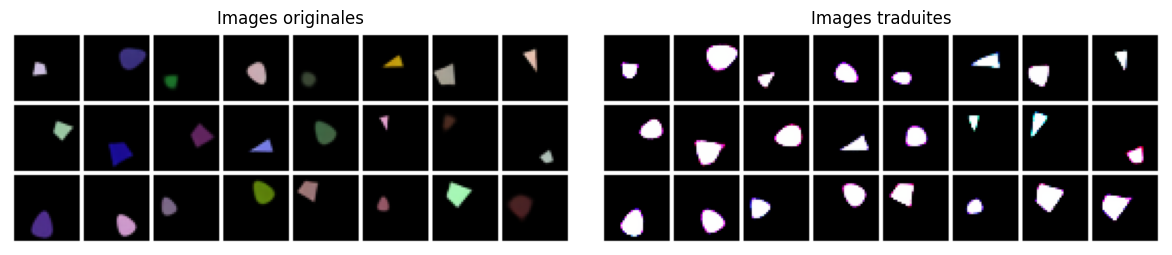

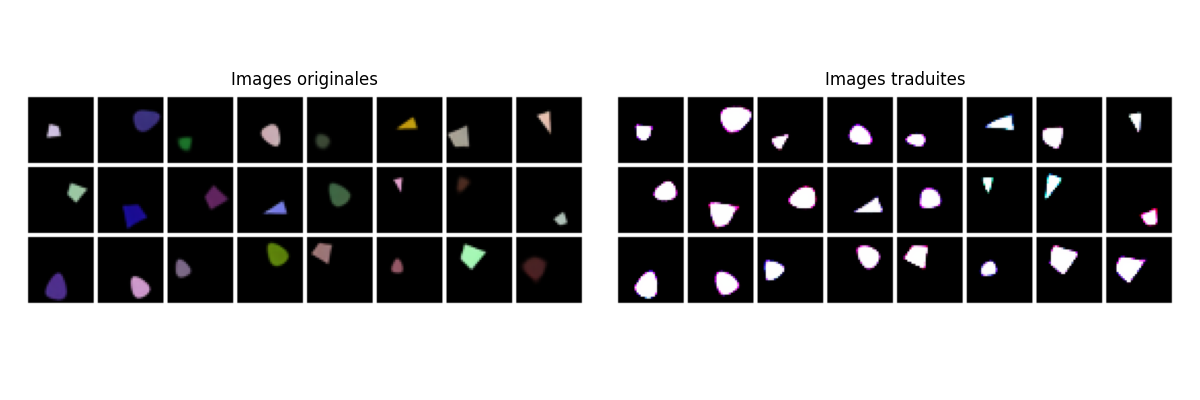

In [3]:
project_name = "syn"
condition = "demi_cycle_custom_mini"
data = "biased_00"
switch_epoch = 0

checkpoint_epoch=0

n_samples = 32
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
train_samples = get_data_samples(data_module, n_samples, split ='train')
data_translated = get_data_translated(global_workspace, train_samples, n_samples, fusion_attr_weight, show_results_fusion)

print(data_translated["train_attr"][0:3])
print(data_translated["attr_decoded"][0:3])
plot_original_translated_comparison(data_translated["train_images"], data_translated["images_decoded"])

In [4]:
@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    original_image = get_image_from_interactive_attr(cat, x, y, size, rot, color_r, color_g, color_b)
    decoded_image = get_decoded_image_from_interactive_attr(cat, x, y, size, rot, color_r, color_g, color_b, training_params, device, global_workspace)
    plot_interactive(original_image, decoded_image)



interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…

In [5]:
training_params

{'experiment_name': 'demi_cycle_custom_mini_biased_00',
 'exclude_colors': True,
 'apply_custom_init': True,
 'config': Config(seed=124, ood_seed=None, default_root_dir=PosixPath('checkpoints'), dataset=Dataset(path='/home/lucas/gwsyn/simple_shapes_dataset_biased_00'), training=Training(batch_size=300, num_workers=16, devices=1, accelerator='gpu', fast_dev_run=False, max_steps=200000, enable_progress_bar=True, precision=32, float32_matmul_precision='highest', optim=Optim(lr=1e-05, max_lr=0.00015, start_lr=0.0001, end_lr=1e-05, pct_start=0.03, weight_decay=1e-06)), wandb=WanDB(enabled=True, save_dir='./wandb', project='Shimmer-SSD', entity='lexman-psl', reinit=False), logging=Logging(filter_images=['pred_trans_attr_to_attr', 'pred_trans_v_latents_to_v_latents', 'pred_trans_attr_to_v_latents', 'pred_trans_v_latents_to_attr', 'pred_cycle_v_latents_to_attr', 'pred_cycle_attr_to_v_latents', 'pred_cycle_v_latents_to_v_latents', 'pred_cycle_attr_to_attr'], log_train_medias_every_n_epochs=1, l

In [6]:
global_workspace

GlobalWorkspace2Domains(
  (gw_mod): GWModule(
    (domain_mods): ModuleDict(
      (v_latents): VisualLatentDomainModule(
        (visual_module): VisualDomainModule(
          (vae): VAE(
            (encoder): RAEEncoder(
              (layers): Sequential(
                (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
                (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): ReLU()
                (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
                (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (5): ReLU()
                (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
                (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (8): ReLU()
                (9): Conv2d(256, 512, kernel_size=(